In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install numba

In [3]:
import matplotlib.pyplot as plt
from numba import cuda
import numpy as np
import time
import math

Image size: 3167 x 3167
Pixels count: 10029889


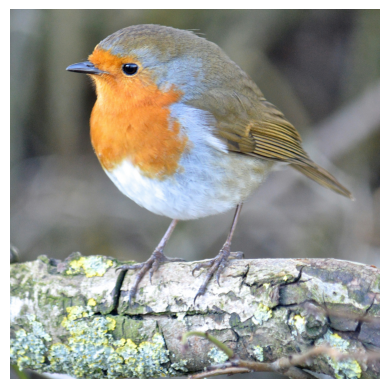

In [4]:
img = plt.imread('/content/drive/MyDrive/Dataset/HPC/bigger_bird.jpg')
h, w, _ = img.shape
pixelCount = h * w

print(f"Image size: {h} x {w}")
print(f"Pixels count: {pixelCount}")

plt.imshow(img)
plt.axis("off")
plt.show()

**GPU Computation with 1D Block size**

GPU time with block size = 64: 0.1105s


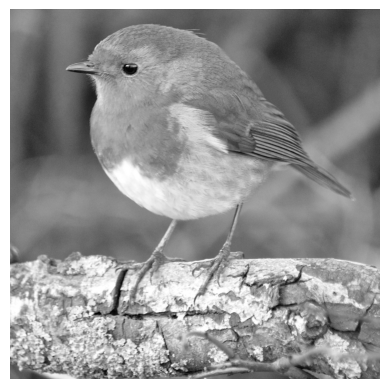

In [13]:
@cuda.jit
def rgb2gray_gpu(rgb, gray):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  g = np.uint8((rgb[tidx, 0] + rgb[tidx, 1] + rgb[tidx, 2]) / 3)
  gray[tidx, 0] = gray[tidx, 1] = gray[tidx, 2] = g

def grayscale_gpu(flatten_rgb, blockSize):
  gridSize = (pixelCount + blockSize - 1) // blockSize
  rgb_gpu = cuda.to_device(flatten_rgb)
  gray_gpu = cuda.device_array((pixelCount, 3), np.uint8)
  rgb2gray_gpu[gridSize, blockSize](rgb_gpu, gray_gpu)
  host_gray_gpu = gray_gpu.copy_to_host()
  return host_gray_gpu

blockSize = 64
flatten_rgb = img.reshape(pixelCount, 3)
start = time.time()
host_gray_gpu = grayscale_gpu(flatten_rgb, blockSize)
gpu_time = time.time() - start

print(f"GPU time with block size = {blockSize}: {gpu_time:.4f}s")
gray_gpu_img = host_gray_gpu.reshape(h, w, 3)

plt.imshow(gray_gpu_img)
plt.axis("off")
plt.savefig("gray_gpu.jpg", bbox_inches="tight")
plt.show()

**GPU Computation with 2D Block size**

GPU time with 2D block size = (32, 32): 0.1164s


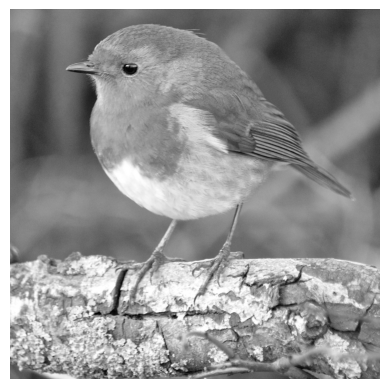

In [23]:
@cuda.jit
def rgb2gray_gpu_2d(rgb, gray):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
  g = np.uint8((rgb[tidy, tidx, 0] + rgb[tidy, tidx, 1] + rgb[tidy, tidx, 2]) / 3)
  gray[tidy, tidx, 0] = gray[tidy, tidx, 1] = gray[tidy, tidx, 2] = g

def grayscale_gpu(rgb, blockSize):
  h, w, _ = rgb.shape
  gridSize = (math.ceil(w / blockSize[0]), math.ceil(h / blockSize[1]))
  rgb_gpu = cuda.to_device(rgb)
  gray_gpu = cuda.device_array((h, w, 3), np.uint8)
  rgb2gray_gpu_2d[gridSize, blockSize](rgb_gpu, gray_gpu)
  host_gray_gpu = gray_gpu.copy_to_host()
  return host_gray_gpu

blockSize = (32, 32)
start = time.time()
host_gray_gpu = grayscale_gpu(img, blockSize)
gpu_time = time.time() - start

print(f"GPU time with 2D block size = {blockSize}: {gpu_time:.4f}s")
gray_gpu_img = host_gray_gpu.reshape(h, w, 3)

plt.imshow(gray_gpu_img)
plt.axis("off")
plt.savefig("gray_gpu_2D.jpg", bbox_inches="tight")
plt.show()


**Experimenting with different 2D block sizes**

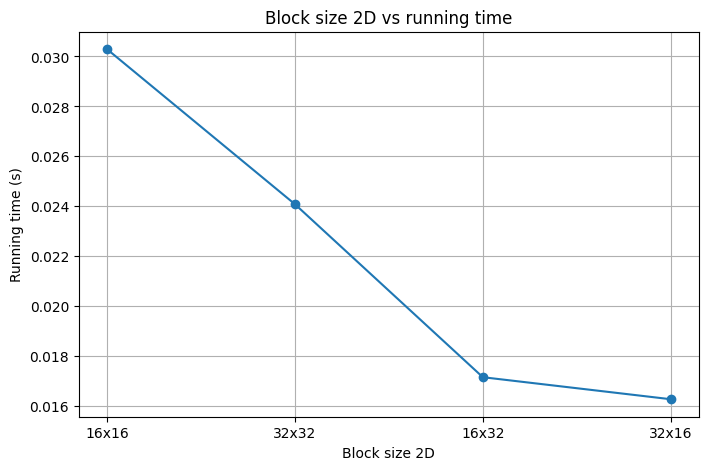

In [27]:
BLOCK_SIZE_2D = [(16, 16), (32, 32), (16, 32), (32, 16)]
running_times = []

for blockSize in BLOCK_SIZE_2D:
  start = time.time()
  host_gray_gpu = grayscale_gpu(img, blockSize)
  running_times.append(time.time() - start)

labels = [f"{x}x{y}" for x, y in BLOCK_SIZE_2D]

plt.figure(figsize=(8, 5))
plt.plot(labels, running_times, marker="o")
plt.xlabel("Block size 2D")
plt.ylabel("Running time (s)")
plt.title("Block size 2D vs running time")
plt.grid(True)
plt.savefig("blocksize_vs_time_2d.png", dpi=150, bbox_inches="tight")
plt.show()
